In [58]:
import pandas as pd
df=pd.read_csv ('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [60]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [61]:
!pip install plotly matplotlib seaborn

In [62]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [63]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

In [10]:
df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

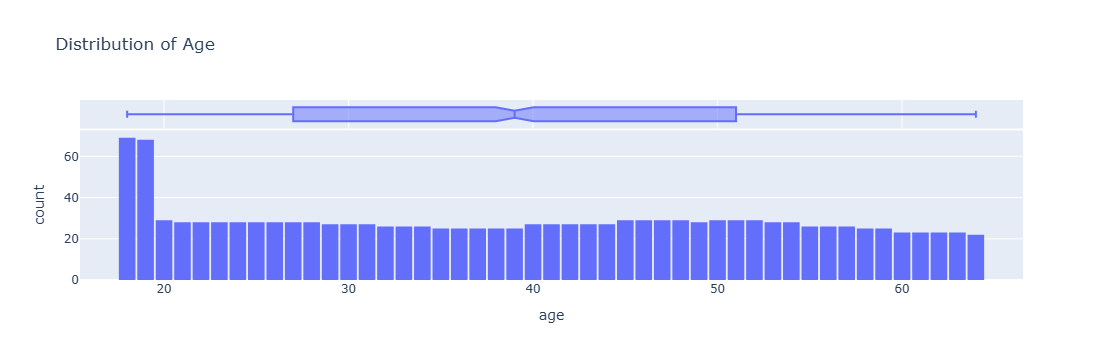

In [11]:
fig = px.histogram(df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()
                   

In [12]:
fig = px.histogram(df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI(Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()
                   

In [13]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green','grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [14]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [15]:
px.histogram(df,x='smoker',color='sex',title='Smoker')

In [16]:
fig = px.scatter(df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

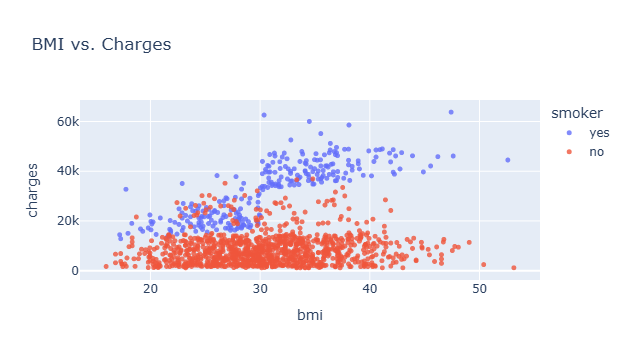

In [17]:
fig = px.scatter(df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [18]:
df.charges.corr(df.age)

np.float64(0.29900819333064765)

In [19]:
df.charges.corr(df.bmi)

np.float64(0.19834096883362892)

In [20]:
smoker_values = {'no':0,'yes':1}
smoker_numeric= df.smoker.map(smoker_values)
df.charges.corr(smoker_numeric)

np.float64(0.7872514304984772)

In [21]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()
correlation

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


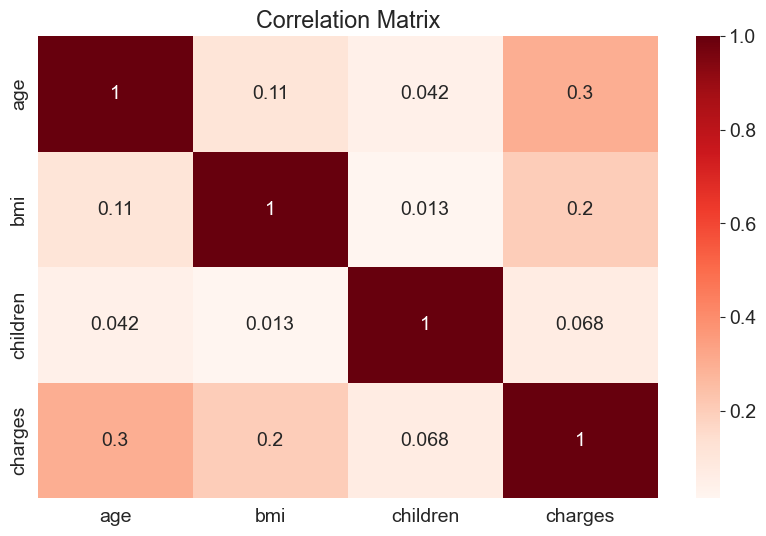

In [22]:
sns.heatmap(correlation,cmap='Reds',annot=True)
plt.title('Correlation Matrix');

In [23]:
smoker_df=df[df.smoker=='yes']

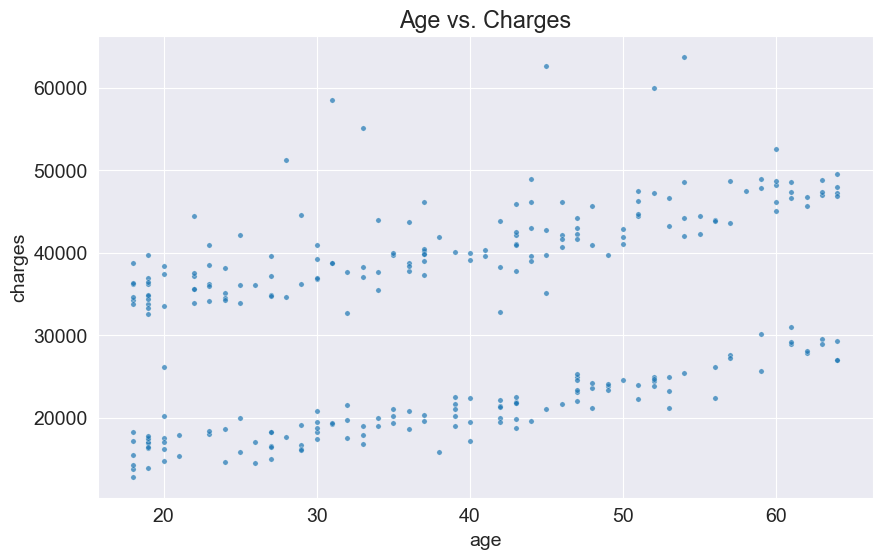

In [24]:
plt.title('Age vs. Charges')
sns.scatterplot(data=smoker_df,x='age',y='charges',alpha=0.7,s=15);

In [28]:
def estimate_charges(age,w,b):
    return w*age+b
w=50
b=2000

In [29]:
estimate_charges(30,w,b)

3500

In [30]:
ages=smoker_df.age
ages

0       19
11      62
14      27
19      30
23      34
        ..
1313    19
1314    30
1321    62
1323    42
1337    61
Name: age, Length: 274, dtype: int64

In [31]:
estimated_charges=estimate_charges(ages,w,b)
estimated_charges

0       2950
11      5100
14      3350
19      3500
23      3700
        ... 
1313    2950
1314    3500
1321    5100
1323    4100
1337    5050
Name: age, Length: 274, dtype: int64

In [32]:
smoker_df.charges

0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

In [33]:
targets = smoker_df.charges
predictions=estimated_charges

In [34]:
!pip install numpy

In [35]:
import numpy as np

In [36]:
def rmse(targets,preditions):
    return np.sqrt(np.mean(np.square(targets-predictions)))

In [37]:
def try_parameters(w,b):
    ages = smoker_df.age
    target = smoker_df.charges
    predictions = estimate_charges(ages,w,b)
    
    plt.plot(ages,predictions,'r',alpha=0.9);
    plt.scatter(ages,target,s=8,alpha=0.8);
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Prediction','Actual']);
    
    loss = rmse(target, predictions)
    print('RMSE Loss: ', loss)
    

RMSE Loss:  30303.3997856249


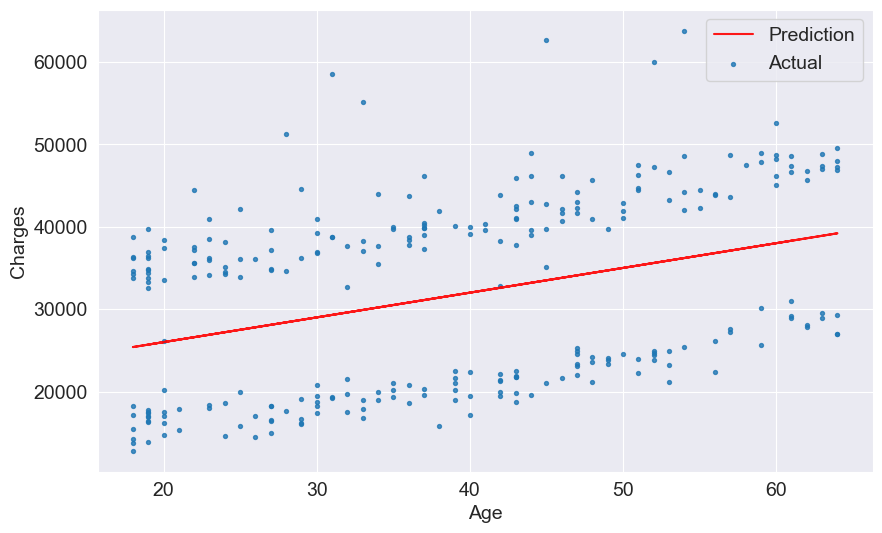

In [38]:
try_parameters(300,20000)

In [39]:
!pip install scikit-learn

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
model = LinearRegression()

In [42]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [43]:
inputs = smoker_df[['age']]
targets = smoker_df.charges
print('inputs.shape:',inputs.shape)
print('targets.shape:',targets.shape)

inputs.shape: (274, 1)
targets.shape: (274,)


In [44]:
model.fit(inputs,targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
model.predict(np.array([[23],
                        [37],
                        [61]]))

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([27314.59297544, 31587.91940498, 38913.62185562])

In [46]:
predictions=model.predict(inputs)

In [47]:
predictions

array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865, 29756.49379232, 27009.35537333, 28840.78098599,
       30977.44420076, 38608.38425351, 31282.68180287, 34945.53302819,
       31282.68180287, 37997.90904929, 25788.40496489, 36471.72103874,
       26398.88016911, 28840.78098599, 28535.54338388, 27009.35537333,
       31587.91940498, 34029.82022186, 37692.67144718, 38303.1466514 ,
       39829.33466195, 37387.43384507, 31893.15700709, 38913.62185562,
       26398.88016911, 39524.09705984, 29146.0185881 , 33724.58261975,
       26093.642567  , 30061.73139443, 30672.20659865, 29451.25619021,
       34335.05782397, 33114.10741553, 34945.53302819, 25788.40496489,
       29451.25619021, 33114.10741553, 25788.40496489, 39524.09705984,
       31282.68180287, 28535.54338388, 30977.44420076, 26093.642567  ,
       33114.10741553, 32503.63221131, 26093.642567  , 27314.59297544,
       39524.09705984, 25788.40496489, 39524.09705984, 36776.95864085,
      

In [48]:
targets

0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

In [49]:
rmse(targets,predictions)

np.float64(10711.00334810241)

In [50]:
model.coef_

array([305.23760211])

In [51]:
model.intercept_

np.float64(20294.12812691597)

RMSE Loss:  10711.00334810241


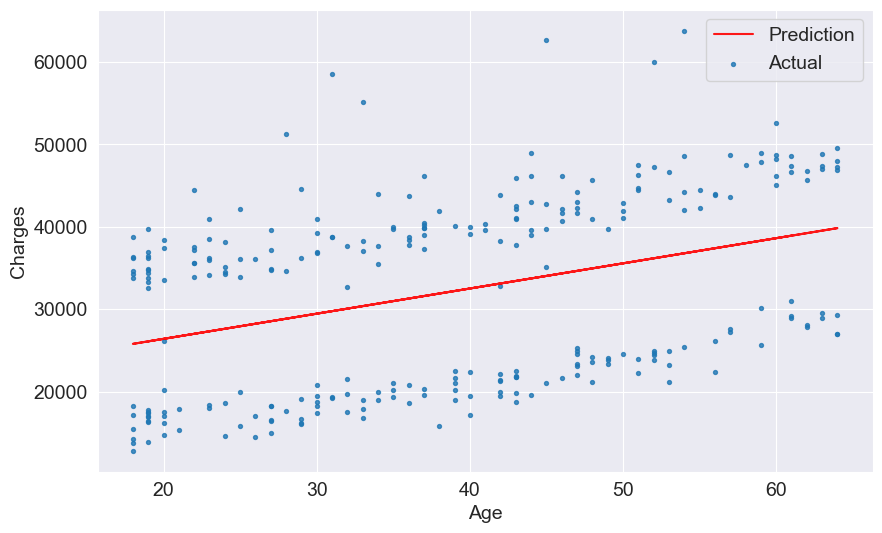

In [52]:
try_parameters(model.coef_,model.intercept_)

<Axes: xlabel='smoker', ylabel='charges'>

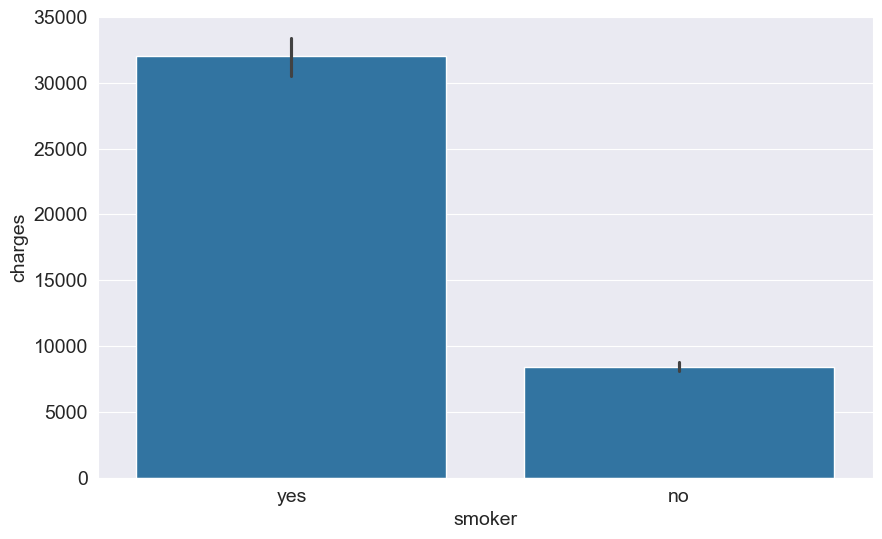

In [54]:
sns.barplot(data=df,x='smoker',y='charges')

In [55]:
smoker_codes ={'no':0,'yes':1}
df['smoker_code']=df.smoker.map(smoker_codes)

In [56]:
df.charges.corr(df.smoker_code)

np.float64(0.7872514304984772)

In [57]:
df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0
